In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA, NMF, FactorAnalysis, KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import umap
import pacmap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')


def plot_gallery(images, titles=None, h=8, w=8, n_row=2, n_col=3, cmap=plt.cm.gray):
    fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2.2 * n_row))
    axes = axes.ravel()
    for i in range(n_row * n_col):
        axes[i].imshow(images[i].reshape(h, w), cmap=cmap)
        if titles is not None:
            axes[i].set_title(titles[i], fontsize=10)
        axes[i].axis('off')
    plt.tight_layout()


def classification_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }


def evaluate_pipeline(pipeline, X_train, y_train, X_val, y_val):
    pipeline.fit(X_train, y_train)
    results = {}
    for split, X_split, y_split in (
        ('train', X_train, y_train),
        ('val', X_val, y_val),
    ):
        preds = pipeline.predict(X_split)
        results[split] = classification_metrics(y_split, preds)
    return results, pipeline


def plot_confusion(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, ax=ax, cmap='Blues', cbar=False)
    ax.set_title(title)
    ax.set_xlabel('Predykcja')
    ax.set_ylabel('Prawda')


def build_pipeline(method, n_components=None, kernel=None):
    clf = LogisticRegression(max_iter=4000)
    if method == 'baseline':
        return Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    if method == 'pca':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=n_components, random_state=RANDOM_STATE)),
            ('clf', clf),
        ])
    if method == 'nmf':
        return Pipeline([
            ('scaler', MinMaxScaler()),
            ('nmf', NMF(n_components=n_components, init='nndsvda', max_iter=1000, random_state=RANDOM_STATE)),
            ('clf', clf),
        ])
    if method == 'fa':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('fa', FactorAnalysis(n_components=n_components, random_state=RANDOM_STATE)),
            ('clf', clf),
        ])
    if method == 'kpca':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('kpca', KernelPCA(n_components=n_components, kernel=kernel, gamma=1 / 64)),
            ('clf', clf),
        ])
    raise ValueError(f'Nieznana metoda: {method}')


def embed_data(transformer, X_train_scaled, X_val_scaled):
    if isinstance(transformer, pacmap.PaCMAP):
        X_all = np.vstack([X_train_scaled, X_val_scaled])
        X_all_embedded = transformer.fit_transform(X_all)
        return (
            X_all_embedded[: len(X_train_scaled)],
            X_all_embedded[len(X_train_scaled) :],
            'full',
        )
    if hasattr(transformer, 'transform'):
        transformer.fit(X_train_scaled)
        return transformer.transform(X_train_scaled), transformer.transform(X_val_scaled), 'train'
    X_all = np.vstack([X_train_scaled, X_val_scaled])
    X_all_embedded = transformer.fit_transform(X_all)
    return (
        X_all_embedded[: len(X_train_scaled)],
        X_all_embedded[len(X_train_scaled) :],
        'full',
    )

X shape: (1797, 64), y shape: (1797,)


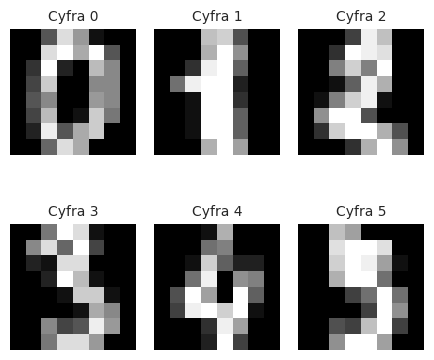

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

print(f'X shape: {X.shape}, y shape: {y.shape}')
plot_gallery(X[:6], titles=[f'Cyfra {label}' for label in y[:6]], n_row=2, n_col=3)

### Podział na zbiór treningowy i walidacyjny

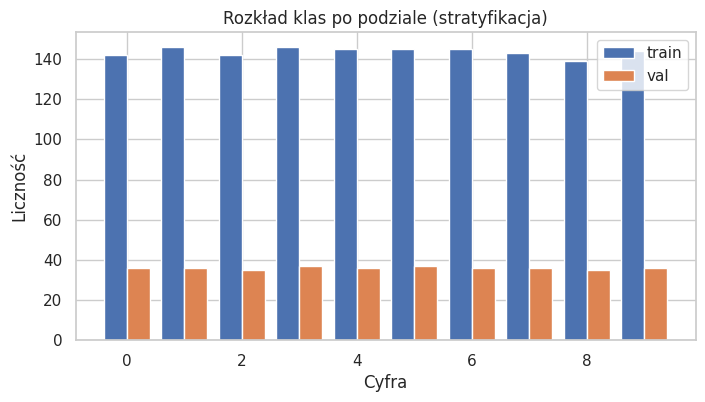

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

class_counts = pd.Series(y).value_counts().sort_index()
class_counts_train = pd.Series(y_train).value_counts().sort_index()
class_counts_val = pd.Series(y_val).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(class_counts.index - 0.2, class_counts_train.values, width=0.4, label='train')
ax.bar(class_counts.index + 0.2, class_counts_val.values, width=0.4, label='val')
ax.set_xlabel('Cyfra')
ax.set_ylabel('Liczność')
ax.set_title('Rozkład klas po podziale (stratyfikacja)')
ax.legend()
plt.show()

### Redukcja wymiarowości — przykładowe rekonstrukcje (n = 32)

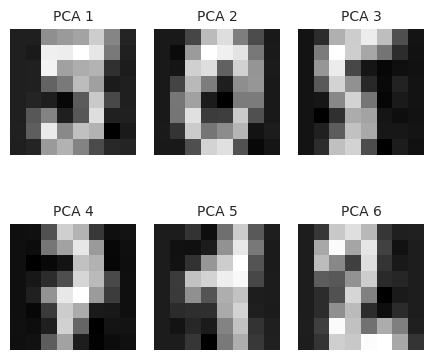

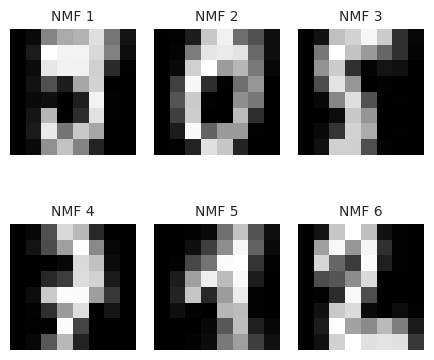

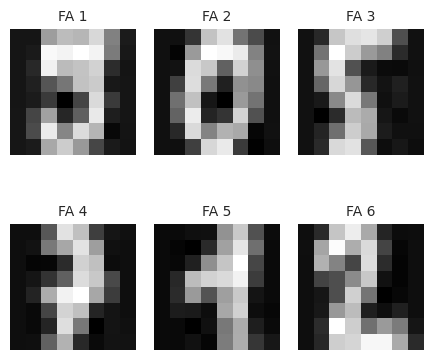

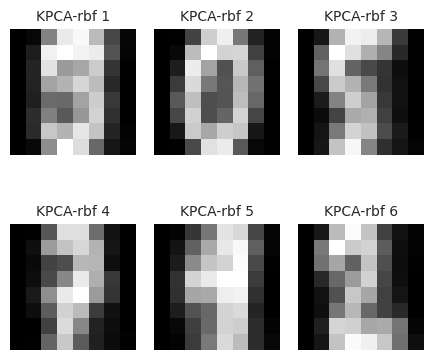

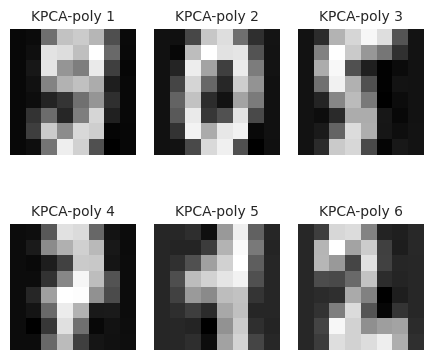

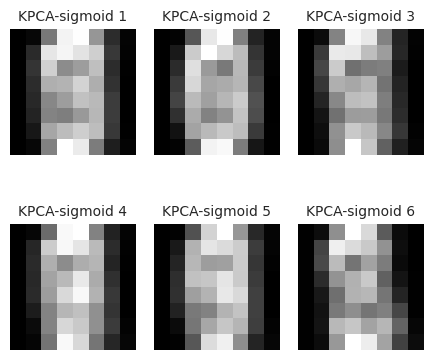

In [4]:
n_components_base = 32
sample = X_train[:6]

pca_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_components_base, random_state=RANDOM_STATE)),
])
pca_pipe.fit(X_train)
pca_recon = pca_pipe.inverse_transform(pca_pipe.transform(sample))
plot_gallery(pca_recon, titles=[f'PCA {i+1}' for i in range(6)], n_row=2, n_col=3)

nmf_pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('nmf', NMF(n_components=n_components_base, init='nndsvda', max_iter=1000, random_state=RANDOM_STATE)),
])
nmf_pipe.fit(X_train)
nmf_recon = nmf_pipe.inverse_transform(nmf_pipe.transform(sample))
plot_gallery(nmf_recon, titles=[f'NMF {i+1}' for i in range(6)], n_row=2, n_col=3)

fa_scaler = StandardScaler()
X_train_scaled = fa_scaler.fit_transform(X_train)
fa = FactorAnalysis(n_components=n_components_base, random_state=RANDOM_STATE)
fa.fit(X_train_scaled)
sample_scaled = fa_scaler.transform(sample)
fa_scores = fa.transform(sample_scaled)
fa_recon_scaled = fa_scores @ fa.components_ + fa.mean_
fa_recon = fa_scaler.inverse_transform(fa_recon_scaled)
plot_gallery(fa_recon, titles=[f'FA {i+1}' for i in range(6)], n_row=2, n_col=3)

kpca_kernels = ['rbf', 'poly', 'sigmoid']
for kernel in kpca_kernels:
    kpca_pipe = Pipeline([
        ('scaler', StandardScaler()),
        (
            'kpca',
            KernelPCA(
                n_components=n_components_base,
                kernel=kernel,
                gamma=1 / 64,
                fit_inverse_transform=True,
            ),
        ),
    ])
    kpca_pipe.fit(X_train)
    kpca_recon = kpca_pipe.inverse_transform(kpca_pipe.transform(sample))
    plot_gallery(kpca_recon, titles=[f'KPCA-{kernel} {i+1}' for i in range(6)], n_row=2, n_col=3)

### Regresja logistyczna — baseline i redukcje (n = 32)

In [5]:
base_models = {
    'Baseline': build_pipeline('baseline'),
    'PCA (32)': build_pipeline('pca', n_components_base),
    'NMF (32)': build_pipeline('nmf', n_components_base),
    'FA (32)': build_pipeline('fa', n_components_base),
    'KPCA-rbf (32)': build_pipeline('kpca', n_components_base, kernel='rbf'),
    'KPCA-poly (32)': build_pipeline('kpca', n_components_base, kernel='poly'),
    'KPCA-sigmoid (32)': build_pipeline('kpca', n_components_base, kernel='sigmoid'),
}

base_results = {}
base_preds_train = {}
base_preds_val = {}

for name, model in base_models.items():
    metrics, fitted = evaluate_pipeline(model, X_train, y_train, X_val, y_val)
    base_results[name] = metrics
    base_preds_train[name] = fitted.predict(X_train)
    base_preds_val[name] = fitted.predict(X_val)

base_rows = []
for method, splits in base_results.items():
    for split, metrics in splits.items():
        base_rows.append({'metoda': method, 'zbior': split, **metrics})

base_df = pd.DataFrame(base_rows).set_index(['metoda', 'zbior']).sort_index()
base_df

accuracy  balanced_accuracy  precision_macro  \
metoda            zbior                                                 
Baseline          train  0.999304           0.999306         0.999286   
                  val    0.972222           0.971905         0.972126   
FA (32)           train  0.988170           0.988202         0.988163   
                  val    0.958333           0.957937         0.957187   
KPCA-poly (32)    train  0.956855           0.956996         0.957847   
                  val    0.927778           0.927284         0.928542   
KPCA-rbf (32)     train  0.945024           0.944968         0.946003   
                  val    0.938889           0.938563         0.941754   
KPCA-sigmoid (32) train  0.941545           0.941497         0.942335   
                  val    0.919444           0.919035         0.919703   
NMF (32)          train  0.780097           0.779709         0.788924   
                  val    0.761111           0.761300         0.781996   
PCA (32)          train  0.994433           0.994478         0.994470   
                  val    0.944444           0.944277         0.945083   

                         recall_macro  f1_macro  
metoda            zbior                          
Baseline          train      0.999306  0.999293  
                  val        0.971905  0.971940  
FA (32)           train      0.988202  0.988170  
                  val        0.957937  0.957313  
KPCA-poly (32)    train      0.956996  0.956979  
                  val        0.927284  0.927072  
KPCA-rbf (32)     train      0.944968  0.944941  
                  val        0.938563  0.938630  
KPCA-sigmoid (32) train      0.941497  0.941573  
                  val        0.919035  0.918408  
NMF (32)          train      0.779709  0.773639  
                  val        0.761300  0.747590  
PCA (32)          train      0.994478  0.994448  
                  val        0.944277  0.944316

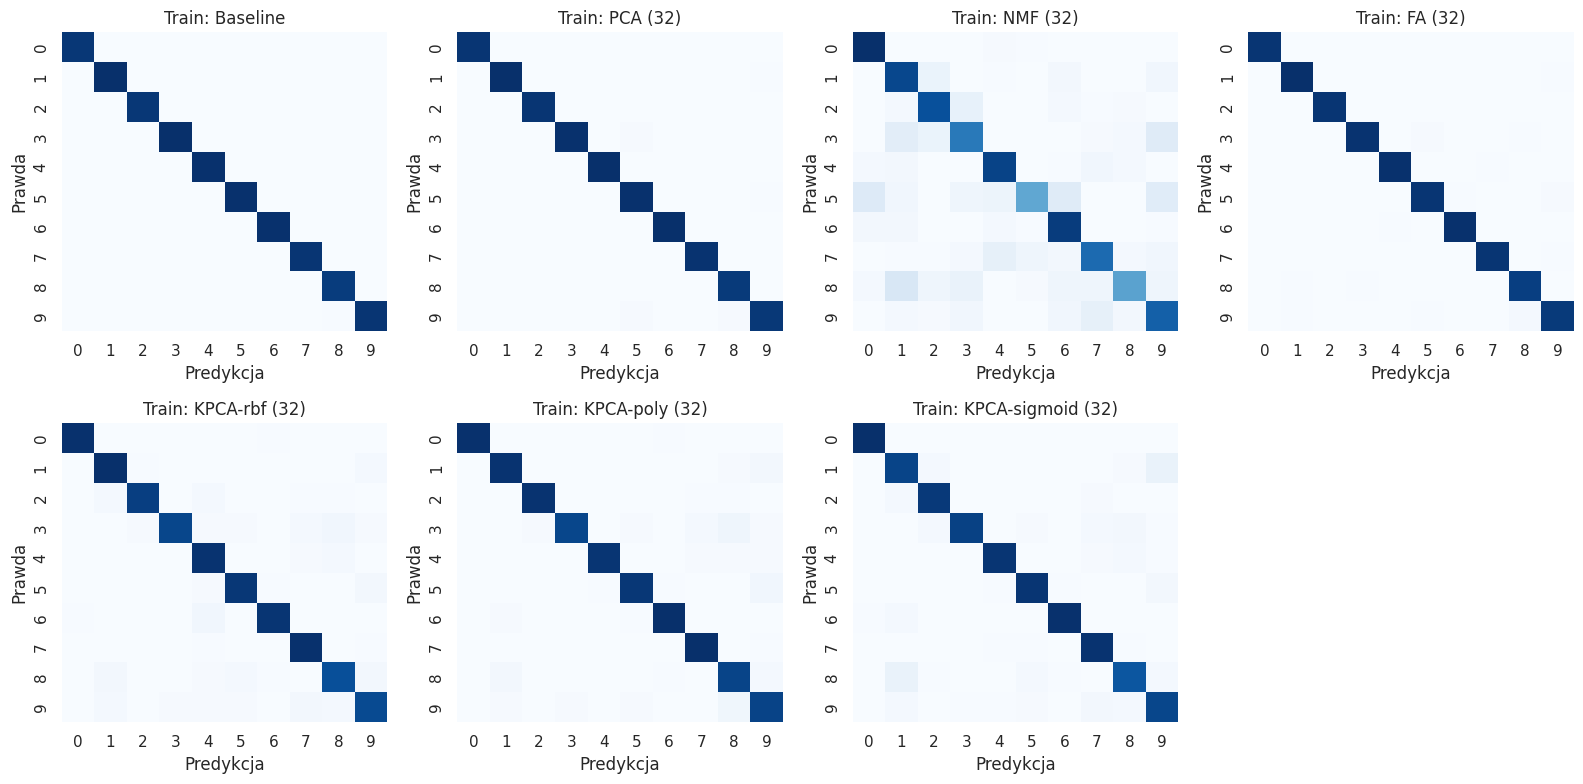

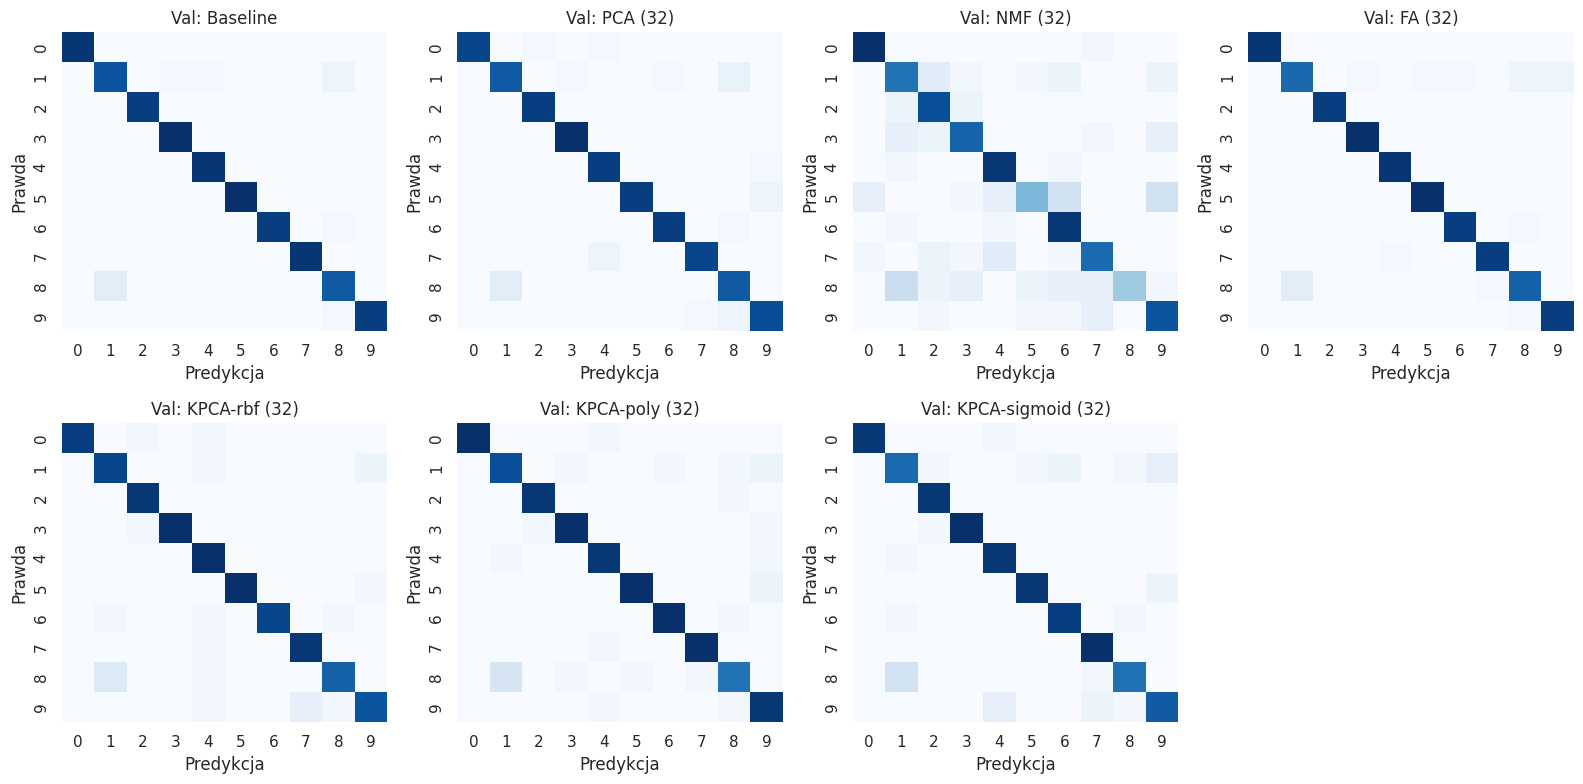

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for ax, (name, preds) in zip(axes, base_preds_train.items()):
    plot_confusion(ax, y_train, preds, f'Train: {name}')

for ax in axes[len(base_preds_train) :]:
    ax.axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for ax, (name, preds) in zip(axes, base_preds_val.items()):
    plot_confusion(ax, y_val, preds, f'Val: {name}')

for ax in axes[len(base_preds_val) :]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Analiza dla n = 32, 16, 8, 4, 2

In [7]:
n_values = [32, 16, 8, 4, 2]
method_builders = {
    'PCA': lambda n: build_pipeline('pca', n),
    'NMF': lambda n: build_pipeline('nmf', n),
    'FA': lambda n: build_pipeline('fa', n),
    'KPCA-rbf': lambda n: build_pipeline('kpca', n, kernel='rbf'),
    'KPCA-poly': lambda n: build_pipeline('kpca', n, kernel='poly'),
    'KPCA-sigmoid': lambda n: build_pipeline('kpca', n, kernel='sigmoid'),
}

sweep_rows = []
conf_matrices_val = {}

for method_name, builder in method_builders.items():
    conf_matrices_val[method_name] = {}
    for n in n_values:
        model = builder(n)
        metrics, fitted = evaluate_pipeline(model, X_train, y_train, X_val, y_val)
        for split, metric_values in metrics.items():
            sweep_rows.append({
                'metoda': method_name,
                'n_components': n,
                'zbior': split,
                **metric_values,
            })
        conf_matrices_val[method_name][n] = confusion_matrix(y_val, fitted.predict(X_val))

sweep_df = pd.DataFrame(sweep_rows)
sweep_df

,metoda,n_components,zbior,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro
0,PCA,32,train,0.994433,0.994478,0.994470,0.994478,0.994448
1,PCA,32,val,0.944444,0.944277,0.945083,0.944277,0.944316
2,PCA,16,train,0.966597,0.966577,0.966814,0.966577,0.966545
3,PCA,16,val,0.927778,0.927293,0.928056,0.927293,0.926992
4,PCA,8,train,0.889353,0.889044,0.890558,0.889044,0.889410
5,PCA,8,val,0.866667,0.865689,0.864619,0.865689,0.863033
6,PCA,4,train,0.803062,0.802186,0.801724,0.802186,0.800891
7,PCA,4,val,0.788889,0.787881,0.781584,0.787881,0.782669
8,PCA,2,train,0.559499,0.558583,0.534037,0.558583,0.537358
9,PCA,2,val,0.525000,0.525363,0.517013,0.525363,0.506808


accuracy           balanced_accuracy            f1_macro  \
zbior            train       val             train       val     train   
n_components                                                             
32            0.994433  0.944444          0.994478  0.944277  0.994448   
16            0.966597  0.927778          0.966577  0.927293  0.966545   
8             0.889353  0.866667          0.889044  0.865689  0.889410   
4             0.803062  0.788889          0.802186  0.787881  0.800891   
2             0.559499  0.525000          0.558583  0.525363  0.537358   

                       precision_macro           recall_macro            
zbior              val           train       val        train       val  
n_components                                                             
32            0.944316        0.994470  0.945083     0.994478  0.944277  
16            0.926992        0.966814  0.928056     0.966577  0.927293  
8             0.863033        0.890558  0.864619     0.889044  0.865689  
4             0.782669        0.801724  0.781584     0.802186  0.787881  
2             0.506808        0.534037  0.517013     0.558583  0.525363

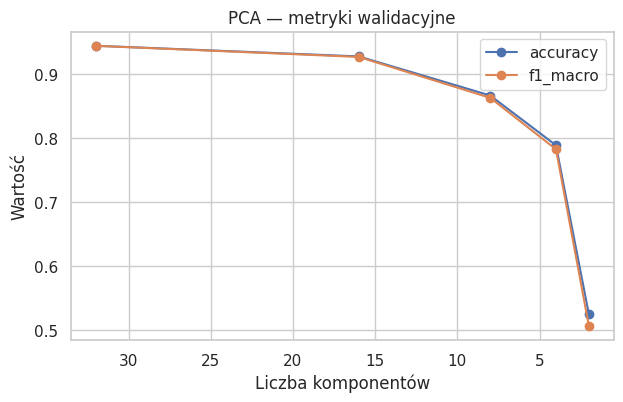

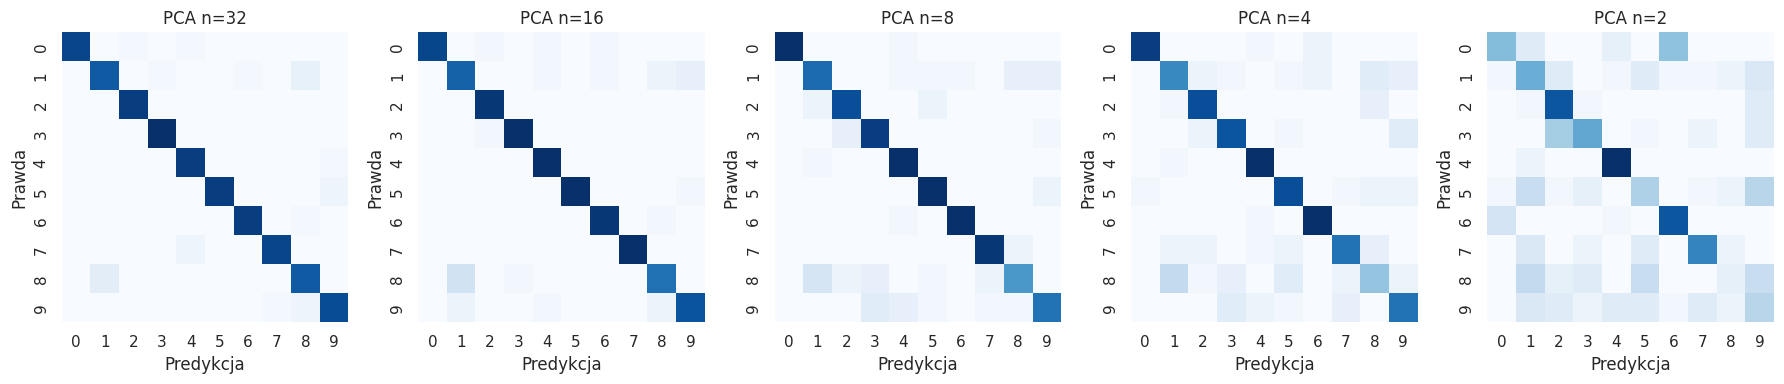

accuracy           balanced_accuracy            f1_macro  \
zbior            train       val             train       val     train   
n_components                                                             
32            0.780097  0.761111          0.779709  0.761300  0.773639   
16            0.837161  0.816667          0.836697  0.815450  0.836355   
8             0.774530  0.761111          0.773094  0.759326  0.758011   
4             0.653445  0.650000          0.652401  0.649695  0.621389   
2             0.320807  0.311111          0.319093  0.309303  0.266724   

                       precision_macro           recall_macro            
zbior              val           train       val        train       val  
n_components                                                             
32            0.747590        0.788924  0.781996     0.779709  0.761300  
16            0.813984        0.846270  0.821551     0.836697  0.815450  
8             0.735905        0.788529  0.782476     0.773094  0.759326  
4             0.616039        0.669229  0.635025     0.652401  0.649695  
2             0.246453        0.256529  0.231047     0.319093  0.309303

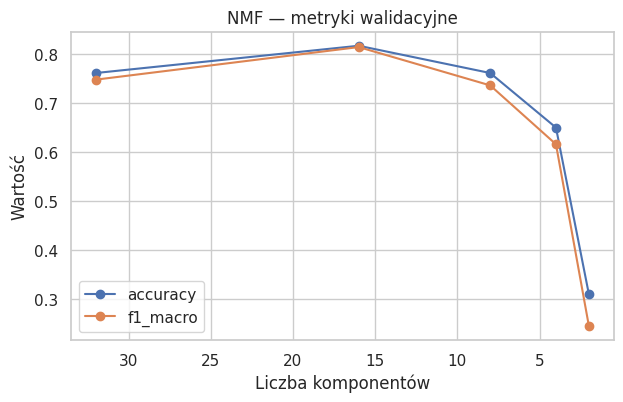

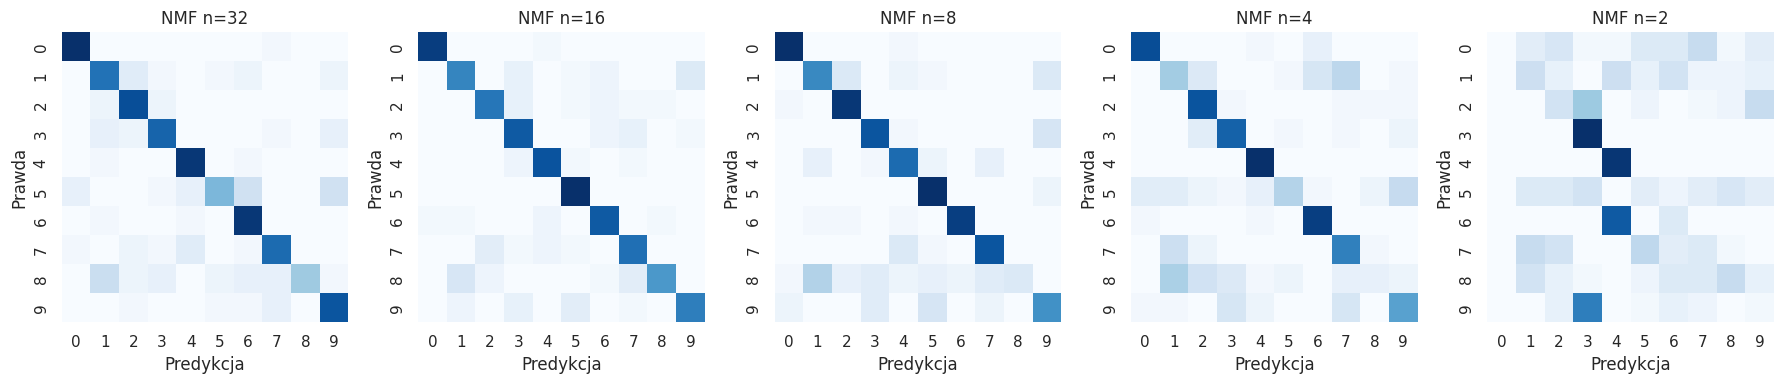

accuracy           balanced_accuracy            f1_macro  \
zbior            train       val             train       val     train   
n_components                                                             
32            0.988170  0.958333          0.988202  0.957937  0.988170   
16            0.963814  0.930556          0.963774  0.930071  0.963661   
8             0.886569  0.877778          0.886152  0.876574  0.885814   
4             0.783577  0.747222          0.783002  0.746426  0.781548   
2             0.480167  0.450000          0.479619  0.450500  0.444360   

                       precision_macro           recall_macro            
zbior              val           train       val        train       val  
n_components                                                             
32            0.957313        0.988163  0.957187     0.988202  0.957937  
16            0.929284        0.963827  0.930873     0.963774  0.930071  
8             0.874574        0.886368  0.875597     0.886152  0.876574  
4             0.741130        0.782905  0.742536     0.783002  0.746426  
2             0.410517        0.436672  0.408703     0.479619  0.450500

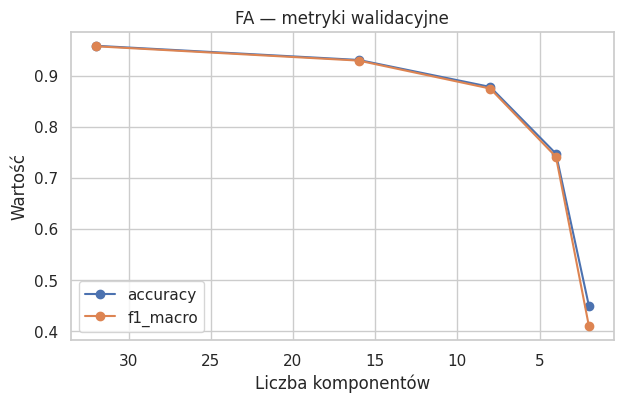

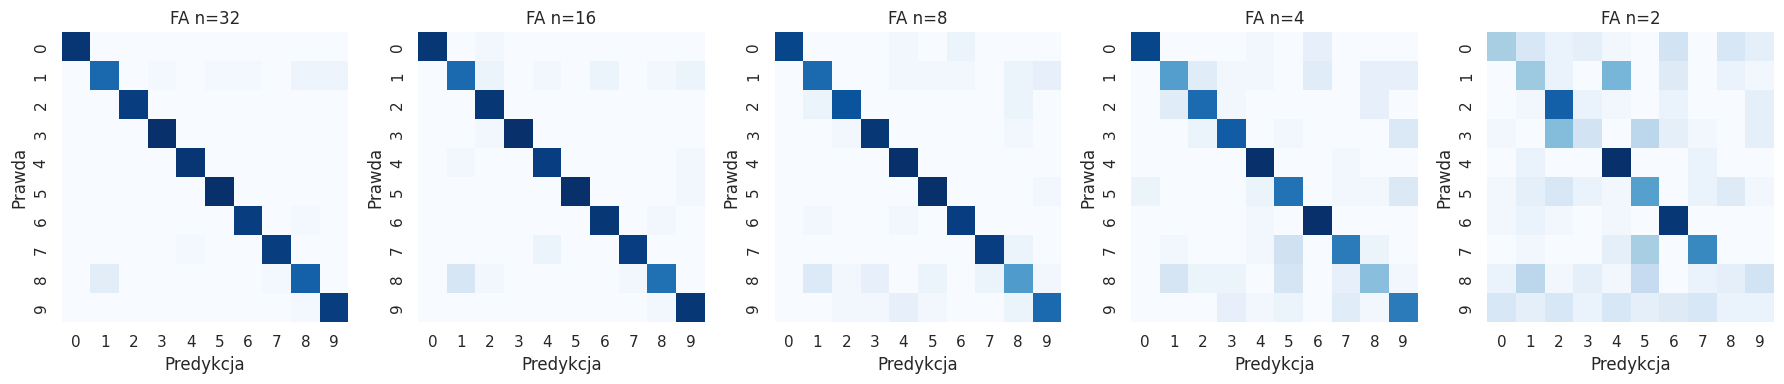

accuracy           balanced_accuracy            f1_macro  \
zbior            train       val             train       val     train   
n_components                                                             
32            0.945024  0.938889          0.944968  0.938563  0.944941   
16            0.929715  0.919444          0.929666  0.918792  0.929709   
8             0.859429  0.822222          0.859246  0.821156  0.858317   
4             0.736256  0.691667          0.736172  0.691697  0.735415   
2             0.589422  0.600000          0.587750  0.598576  0.568990   

                       precision_macro           recall_macro            
zbior              val           train       val        train       val  
n_components                                                             
32            0.938630        0.946003  0.941754     0.944968  0.938563  
16            0.918578        0.930774  0.922014     0.929666  0.918792  
8             0.817186        0.859461  0.820077     0.859246  0.821156  
4             0.689532        0.740494  0.699451     0.736172  0.691697  
2             0.589327        0.562656  0.595283     0.587750  0.598576

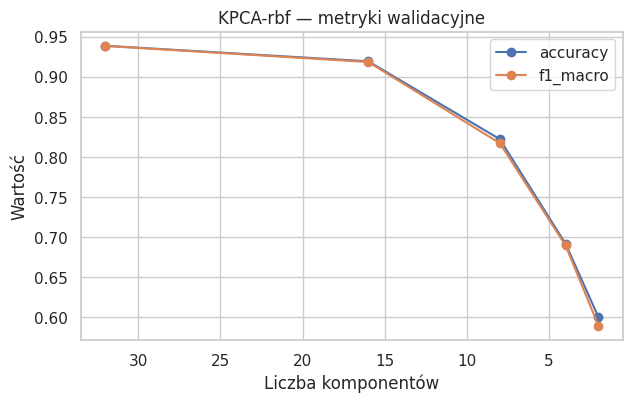

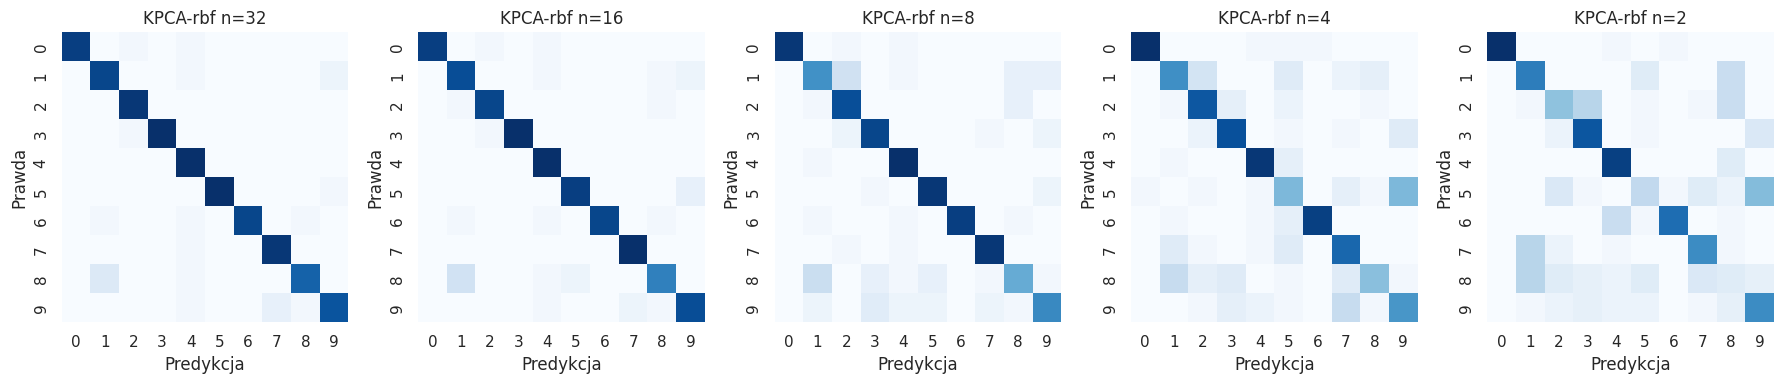

accuracy           balanced_accuracy            f1_macro  \
zbior            train       val             train       val     train   
n_components                                                             
32            0.956855  0.927778          0.956996  0.927284  0.956979   
16            0.820459  0.786111          0.819847  0.785253  0.819183   
8             0.492693  0.477778          0.491720  0.477673  0.444661   
4             0.259569  0.247222          0.256595  0.244219  0.179659   
2             0.189979  0.158333          0.187199  0.156381  0.102977   

                       precision_macro           recall_macro            
zbior              val           train       val        train       val  
n_components                                                             
32            0.927072        0.957847  0.928542     0.956996  0.927284  
16            0.782393        0.822569  0.782540     0.819847  0.785253  
8             0.424370        0.529183  0.405637     0.491720  0.477673  
4             0.168747        0.332932  0.247362     0.256595  0.244219  
2             0.086078        0.224068  0.131192     0.187199  0.156381

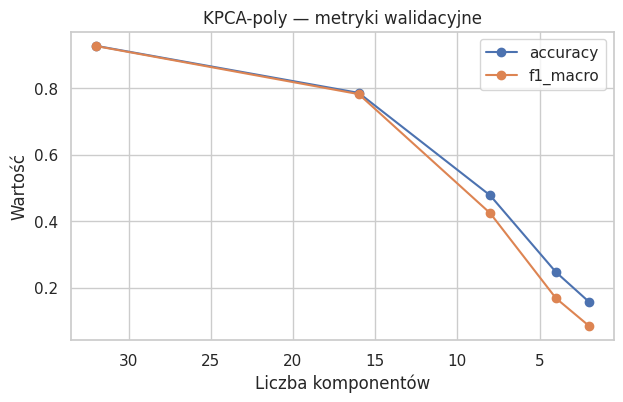

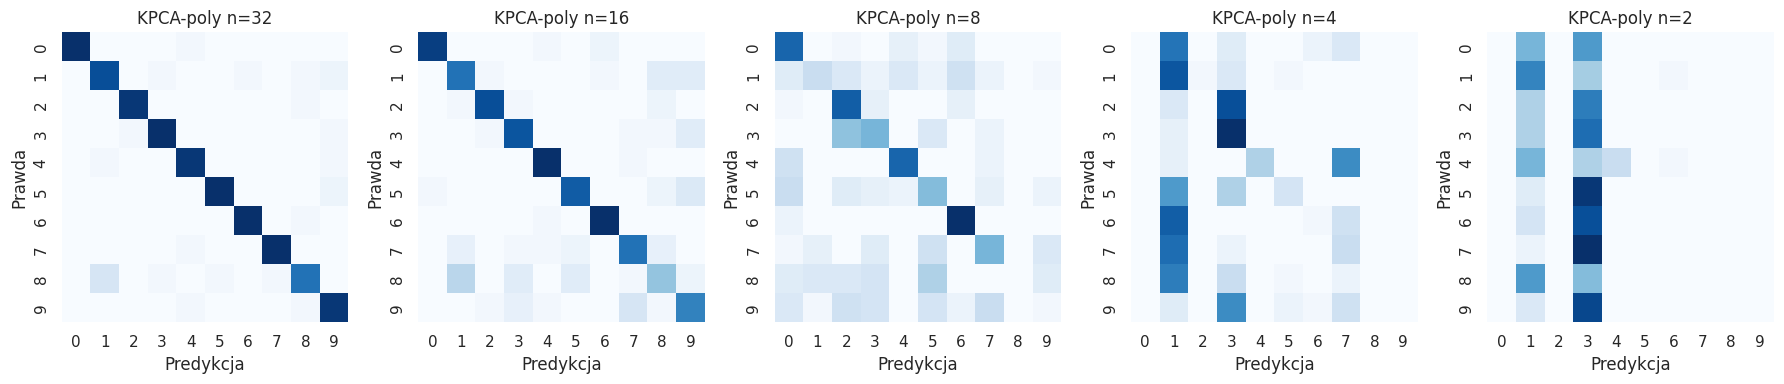

accuracy           balanced_accuracy            f1_macro  \
zbior            train       val             train       val     train   
n_components                                                             
32            0.941545  0.919444          0.941497  0.919035  0.941573   
16            0.931802  0.913889          0.931845  0.913400  0.931902   
8             0.845511  0.825000          0.844292  0.823546  0.837097   
4             0.764092  0.736111          0.762375  0.735073  0.748422   
2             0.499652  0.480556          0.498470  0.481281  0.454504   

                       precision_macro           recall_macro            
zbior              val           train       val        train       val  
n_components                                                             
32            0.918408        0.942335  0.919703     0.941497  0.919035  
16            0.912652        0.932787  0.914284     0.931845  0.913400  
8             0.812908        0.850403  0.828845     0.844292  0.823546  
4             0.717189        0.760195  0.738959     0.762375  0.735073  
2             0.427674        0.476179  0.432138     0.498470  0.481281

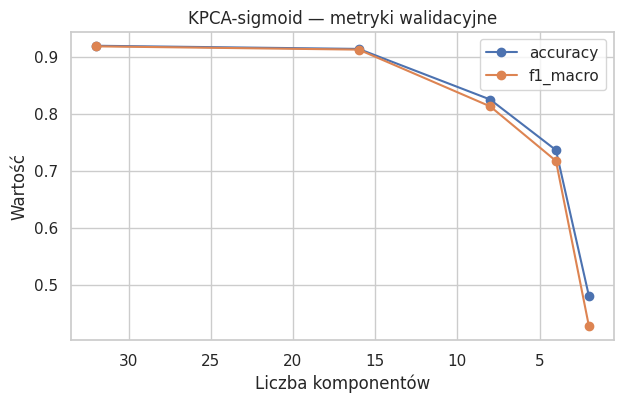

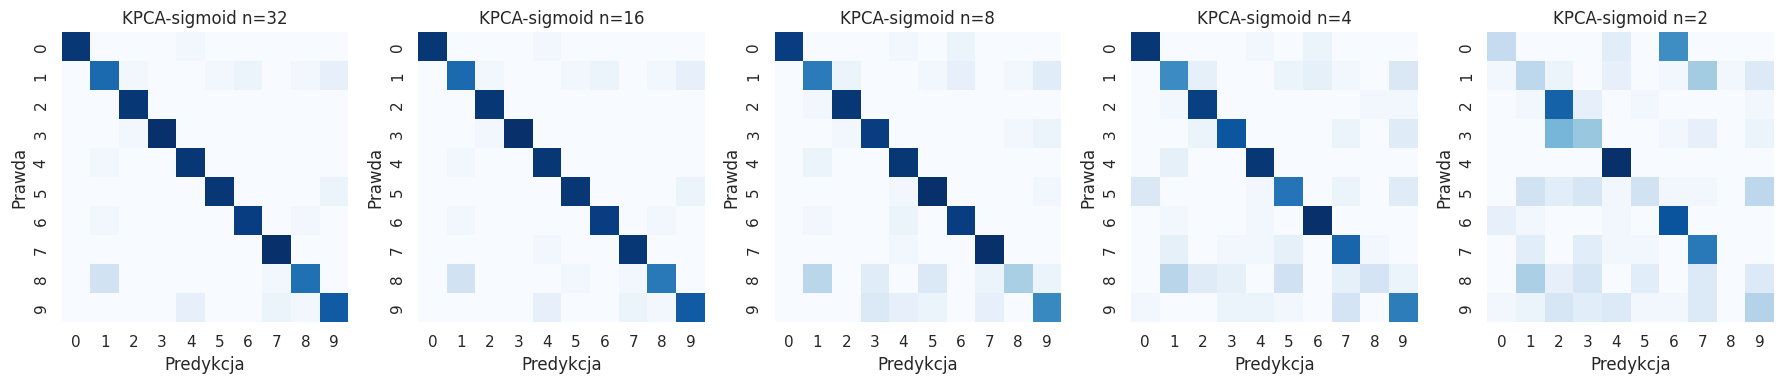

In [8]:
for method_name in method_builders.keys():
    method_df = sweep_df[sweep_df['metoda'] == method_name]
    display(
        method_df.pivot_table(
            index='n_components',
            columns='zbior',
            values=['accuracy', 'balanced_accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        ).sort_index(ascending=False)
    )

    val_metrics = method_df[method_df['zbior'] == 'val'].sort_values('n_components', ascending=False)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(val_metrics['n_components'], val_metrics['accuracy'], marker='o', label='accuracy')
    ax.plot(val_metrics['n_components'], val_metrics['f1_macro'], marker='o', label='f1_macro')
    ax.set_title(f'{method_name} — metryki walidacyjne')
    ax.set_xlabel('Liczba komponentów')
    ax.set_ylabel('Wartość')
    ax.invert_xaxis()
    ax.legend()
    plt.show()

    fig, axes = plt.subplots(1, len(n_values), figsize=(18, 4))
    for ax, n in zip(axes, n_values):
        sns.heatmap(conf_matrices_val[method_name][n], ax=ax, cmap='Blues', cbar=False)
        ax.set_title(f'{method_name} n={n}')
        ax.set_xlabel('Predykcja')
        ax.set_ylabel('Prawda')
    plt.tight_layout()
    plt.show()

- Najwyższe wyniki daje model bez redukcji (accuracy ~0.97). Spośród redukcji najlepiej wypada FA (32), następnie PCA i KPCA (rbf), a NMF wyraźnie odstaje.
- Dla mniejszej liczby komponentów (≤16) widać szybki spadek jakości, szczególnie dla PCA/FA oraz KPCA z jądrem wielomianowym. 32 komponenty to sensowny kompromis między redukcją a jakością.
- NMF wymaga wejścia nieujemnego i przy tej liczbie komponentów zachowuje mniej informacji o kształtach cyfr, co widać w gorszych metrykach.
- Redukcja wymiarowości nie jest tu konieczna do uzyskania wysokiej skuteczności, ale FA lub PCA mogą być użyteczne, gdy liczy się kompresja i szybkie uczenie.
- Usprawnienie: dobrać liczbę komponentów i parametry metod (np. gamma, degree) przez walidację krzyżową oraz porównać z metodami nadzorowanymi (np. LDA) lub nieliniowym klasyfikatorem.

## Metody nieliniowe

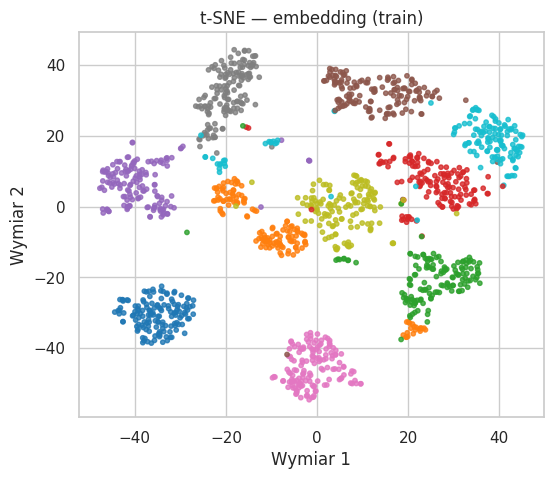

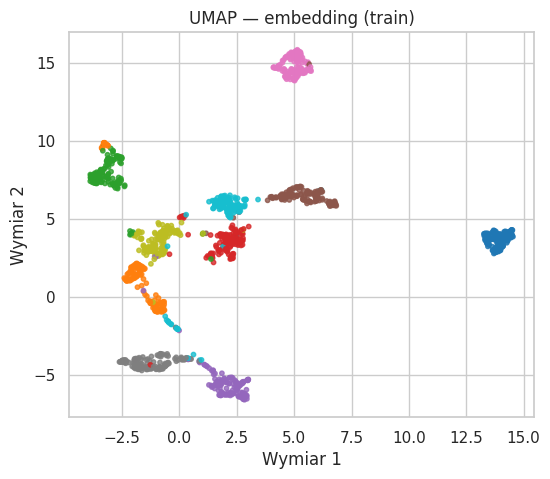

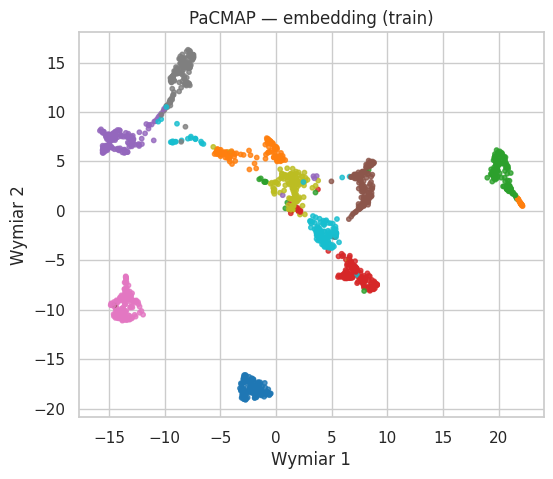

fit_scope  accuracy  balanced_accuracy  precision_macro  \
metoda zbior                                                           
PaCMAP train      full  0.877523           0.877247         0.879798   
       val        full  0.872222           0.871482         0.874908   
UMAP   train     train  0.929019           0.929101         0.930002   
       val       train  0.894444           0.893713         0.903166   
t-SNE  train      full  0.903967           0.903999         0.903114   
       val        full  0.905556           0.905300         0.907415   

              recall_macro  f1_macro  
metoda zbior                          
PaCMAP train      0.877247  0.877461  
       val        0.871482  0.871153  
UMAP   train      0.929101  0.928927  
       val        0.893713  0.894313  
t-SNE  train      0.903999  0.903382  
       val        0.905300  0.903670

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

nonlinear_methods = {
    't-SNE': TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=RANDOM_STATE),
    'UMAP': umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE),
    'PaCMAP': pacmap.PaCMAP(n_components=2, random_state=RANDOM_STATE),
}

nonlinear_rows = []

for name, transformer in nonlinear_methods.items():
    X_train_emb, X_val_emb, fit_scope = embed_data(transformer, X_train_scaled, X_val_scaled)
    clf = LogisticRegression(max_iter=4000)
    clf.fit(X_train_emb, y_train)
    preds_train = clf.predict(X_train_emb)
    preds_val = clf.predict(X_val_emb)

    for split_name, y_true, y_pred in (
        ('train', y_train, preds_train),
        ('val', y_val, preds_val),
    ):
        nonlinear_rows.append({
            'metoda': name,
            'zbior': split_name,
            'fit_scope': fit_scope,
            **classification_metrics(y_true, y_pred),
        })

    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(X_train_emb[:, 0], X_train_emb[:, 1], c=y_train, cmap='tab10', s=10, alpha=0.8)
    ax.set_title(f'{name} — embedding (train)')
    ax.set_xlabel('Wymiar 1')
    ax.set_ylabel('Wymiar 2')
    plt.show()

nonlinear_df = pd.DataFrame(nonlinear_rows).set_index(['metoda', 'zbior']).sort_index()
nonlinear_df

- Metody nieliniowe (t-SNE, UMAP, PaCMAP) w 2D dają niższe wyniki niż klasyczne redukcje liniowe i baseline. t-SNE wypada najlepiej, ale wymaga dopasowania na całym zbiorze, co wprowadza przeciek informacji.
- Te techniki są głównie narzędziami wizualizacyjnymi; do klasyfikacji wymagają większej liczby wymiarów lub innego modelu. W tym zadaniu sens ich użycia jest ograniczony.